In [1]:
import numpy as np
import scipy
import matplotlib.pyplot as plt 
import astropy 
import astroquery
import os 
from astropy.table import Table 
from astroquery.gaia import Gaia

The archive is unstable and may perform below expectations. If launching multiple, consecutive, heavy queries through Python, please space them out (e.g., using sleep(1)) to avoid overloading the system. Please contact the Gaia helpdesk in case of questions (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk). Workaround solutions for the issues following the December 2025 infrastructure upgrade: https://www.cosmos.esa.int/web/gaia/news#WorkaroundArchive


# Question 1

<b> A) If we assume that stars in the Solar Neighborhood are distributed uniformly, how should
the number of stars contained within the volume defined by a certain distance from the
Sun vary with distance?

Assuming a stellar density of $\sigma$ within the Solar Neighbor, the total number of stars in the Solar Neighborhood ($N$) can be found by multiplying $$ N = \sigma V_{SN}$$ where $V_{SN}$ is the volume of the Solar Neighborhood. Since the stars are uniformly distributed, for any radius within the Solar Neighbor, it is true that $$\sigma = \frac{N_{\text{stars in volume}}}{V} = \frac{N_\text{total}}{V_{SN}}$$ So, the number of stars within a radius can be found by multiplying $$N = \sigma V = \sigma \frac{4}{3} \pi r^3$$ where $r$ is the distance from the sun. So the number of stars contained within a volume vary by $r^3$

<b> B) Query the Gaia catalog to determine the number of stars contained within the volume vary as a function of distance out to 100pc. Does the change in the number of stars with volume increase with distance in the way you expected? 

In [3]:
distance =np.linspace(0.5, 100, 10) # pc 
count = []
for d in distance: 
    p = 1/d
    p = p * 1E3 # in mas 
    query = f"SELECT COUNT(parallax) \
    FROM gaiadr2.gaia_source \
    WHERE  parallax  > {p};"
    Gaia.launch_job(query)
    j = Gaia.launch_job(query)
    count.append(j.get_results()[0][0])


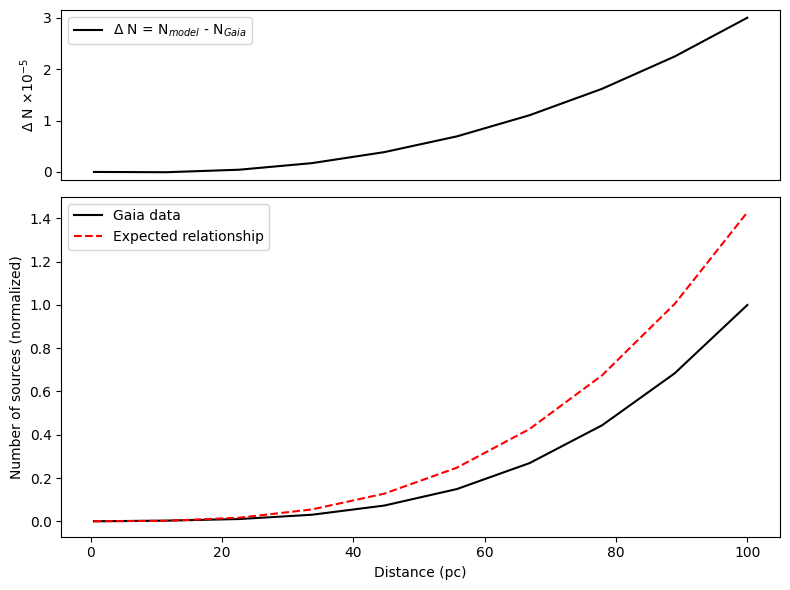

In [5]:
fig, ax = plt.subplots(2,1, figsize = (8,6), gridspec_kw={'height_ratios': [1,2]})
ax[1].plot(distance, count/np.max(count), color = 'k', label = 'Gaia data')
ax[1].plot(distance, distance**3/np.max(count), color = 'r',linestyle = '--', label = 'Expected relationship')
ax[1].set_ylabel('Number of sources (normalized)')
ax[1].set_xlabel("Distance (pc)")
diff = (distance**3 - count)
ax[0].plot(distance, diff *1E-5, color = 'k', label = r'$\Delta$ N = N$_{model}$ - N$_{Gaia}$')
ax[0].xaxis.set_visible(False)
ax[0].set_ylabel(r'$\Delta$ N $\times 10^{-5}$ ')
plt.tight_layout()
ax[1].legend()
ax[0].legend()
plt.savefig('figures/problem1b.png', dpi = 300)

<b> Answer: </b> Generally, yes. The number of sources seen by Gaia follows an $r^3$ fairly well, especially for $d < 40$ pc. While the residual between the expected model and the actual data increases at greater distances, this is expected due to Gaia's observational constraints. Although most nearby stars should fall within Gaia's magnitude limit of ~20, Gaia does not compute parallaxes for all objects it sees. These limitations in combination with the sources that were likely discarded due to low S/N ratios, binaries that may have been discarded due to not appearing point-like, and natural fluctuations in stellar mass density likely account for the disparity seen. 

# Question 2

<b> A) Choose a distance with a large number of stars (this might vary by how powerful your
computer is but aim for ∼10,000; I recommend starting with a smaller number to test
out your code). Query the Gaia catalog for these stars and the parameters you’ll need
for the following calculations.

In [6]:
distance = 100 # pc 
parallax = (1/distance) * 1E3 # mas 
query = f"SELECT parallax, phot_g_mean_mag, bp_rp,teff_val \
    FROM gaiadr2.gaia_source \
    WHERE parallax>{parallax};"

In [7]:
filename ='./data/output.dat'
if not os.path.isfile(filename):
    Gaia.launch_job_async(query, output_file=filename, dump_to_file=True, verbose=True)

/Users/cassiemetzger/opt/anaconda3/envs/a117_env/lib/python3.13/site-packages/astroquery/utils/tap/taputils.py:294: UserWarning: By default, results in votable_gzip format are returned in compressed format therefore your file ./data/output.dat will be renamed to ./data/output.dat.gz
  warnings.warn('By default, results in ' + ", ".join(


Launched query: 'SELECT parallax, phot_g_mean_mag, bp_rp,teff_val     FROM gaiadr2.gaia_source     WHERE parallax>10.0;'
------>https
host = gea.esac.esa.int:443
context = /tap-server/tap/async
Content-type = application/x-www-form-urlencoded
303 303
[('Date', 'Tue, 14 Apr 2026 04:10:10 GMT'), ('Server', 'Apache/2.4.6 (SLES Expanded Support platform 7) OpenSSL/1.0.2k-fips mod_jk/1.2.43'), ('Location', 'https://gea.esac.esa.int/tap-server/tap/async/d4593d8e-37b7-11f1-9e81-bc97e148b76b-O'), ('X-Content-Type-Options', 'nosniff'), ('X-XSS-Protection', '0'), ('Cache-Control', 'no-cache, no-store, max-age=0, must-revalidate'), ('Pragma', 'no-cache'), ('Expires', '0'), ('X-Frame-Options', 'SAMEORIGIN'), ('Set-Cookie', 'SESSION=MDFjY2E0NjEtY2FmNy00OTdmLTg1OGQtNmViOGMxYWI0ZTJi; Path=/tap-server; Secure; HttpOnly; SameSite=Lax'), ('Transfer-Encoding', 'chunked'), ('Content-Type', 'text/plain;charset=UTF-8')]
job d4593d8e-37b7-11f1-9e81-bc97e148b76b-O, at: https://gea.esac.esa.int/tap-server/tap/

In [8]:
results = Table.read(filename)

<b> B) Make a color-magnitude diagram of these stars, with absolute magnitude on the y-axis
and color on the x-axis. Start with phot_g_mean mag (apparent G mag) to determine
your y-axis and bp_rp (BP − RP color) for the x-axis. You’ll need to write a
function to calculate absolute magnitude.
C) Make an HR diagram using teff val (Teff) on the x-axis.

In [9]:
d = 1/(results['parallax']*1E-3) # convert from parallax to distance 
abs_mag_g = results['phot_g_mean_mag'] - (5 * np.log10(d)-5)  # apparent magnitude - dmod

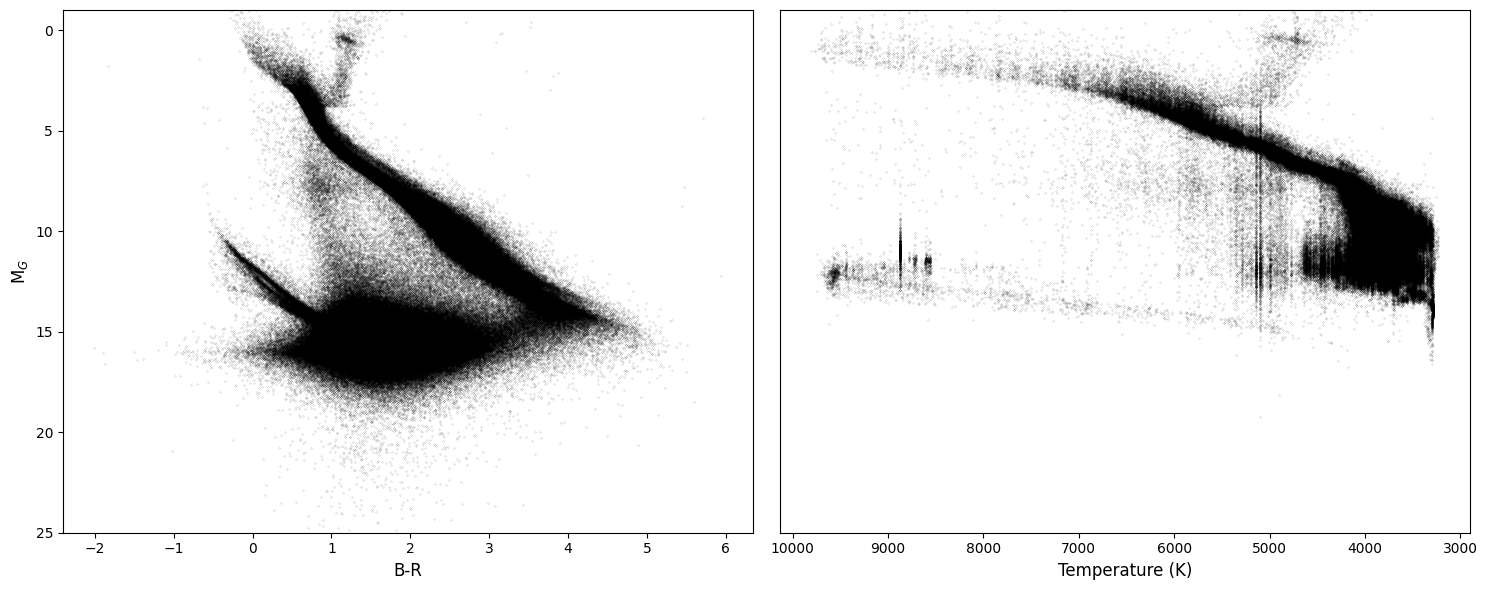

In [10]:
fig, ax = plt.subplots(1,2,figsize = (15,6))
ax[0].scatter(results['bp_rp'], abs_mag_g, s = 0.01, color = 'k', alpha = 0.8)
ax[0].set_xlabel("B-R", fontsize = 12)
ax[0].set_ylabel(r'M$_G$', fontsize = 12)
ax[0].set_ylim(25,-1)
#ax[0].invert_yaxis()
ax[1].scatter(results['teff_val'],abs_mag_g,  s = 0.01, color = 'k', alpha = 0.8)
ax[1].invert_xaxis()
ax[1].set_ylim(25,-1)
ax[1].yaxis.set_visible(False)
ax[1].set_ylabel(r'M$_G$ (mag)', fontsize = 12)
ax[1].set_xlabel('Temperature (K)', fontsize = 12)
plt.tight_layout()
plt.savefig('./figures/problem2bc.png', dpi=300)

<b> D) Do you see any odd behavior in the data? Do the Gaia temperatures seem reasonable? Are there stars missing temperatures or colors? Discuss any other issues you may find. </b>

<b> Answer: </b> The color-magnitude diagram in particular seems reasonable. Although, there is a substantial cluster that seems to fall around ~15 mag, just below the main sequence, but not really in the expected region for WDs (and that seems like wayyy to many WDs). This cluster seems to appear on the HR diagram, but its hard to tell because the HR diagram cuts off pretty strongly at T = 3229.0 K, leaving the main sequence incomplete. The data that is present on the HR diagram looks reasonable (the majority seem to fall fairly close to the temperature of our sun, which makes sense), but it's clear that effective temperatures are missing for a significant portion of sources. Since I was curious about the ~15 mag cluster that seems to appear on both plots, I theorized that this portion of sources might be, at least in part, due to dust reddening, which should increase with distance. So, I recreated the same plot, but with a colormap displaying the distance to the source.  

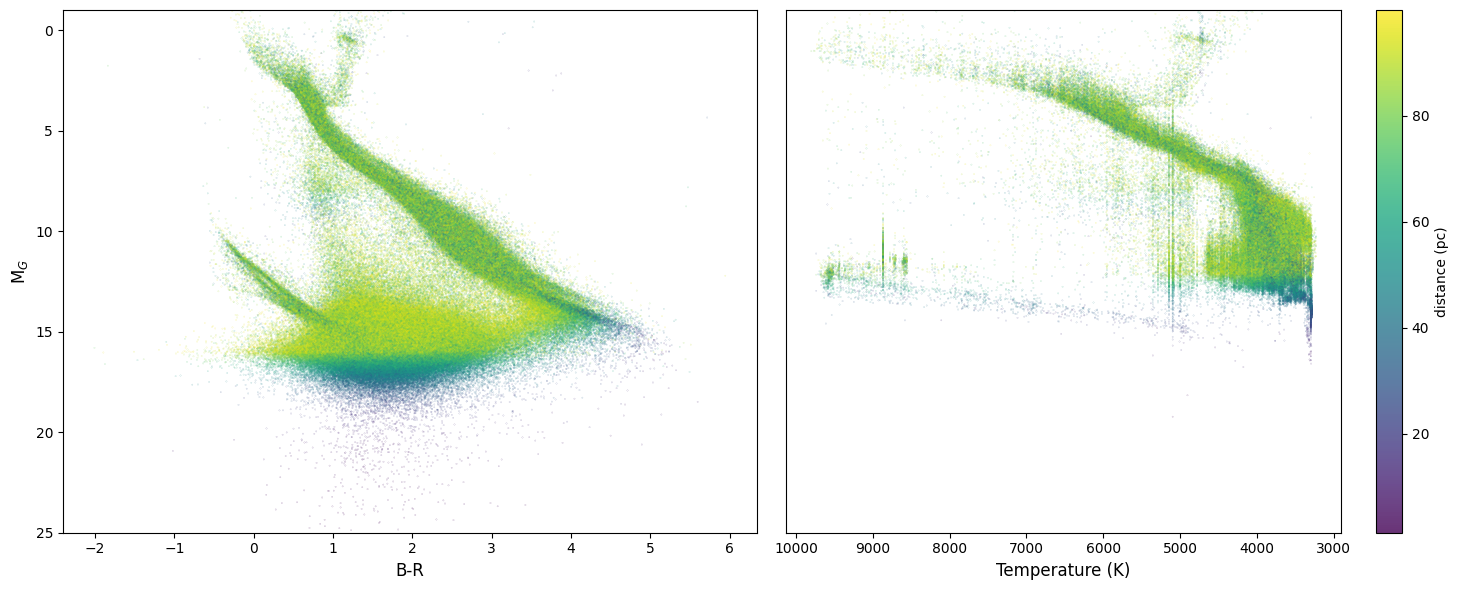

In [11]:
fig, ax = plt.subplots(1,2,figsize = (15,6))
sc1 = ax[0].scatter(results['bp_rp'], abs_mag_g, c = d, cmap = 'viridis', s = 0.01,  alpha = 0.8)
ax[0].set_xlabel("B-R", fontsize = 12)
ax[0].set_ylabel(r'M$_G$', fontsize = 12)
ax[0].set_ylim(25,-1)
#ax[0].invert_yaxis()
sc2 = ax[1].scatter(results['teff_val'],abs_mag_g,  c = d, cmap = 'viridis', s = 0.01,  alpha = 0.8)
ax[1].invert_xaxis()
ax[1].set_ylim(25,-1)
ax[1].yaxis.set_visible(False)
ax[1].set_ylabel(r'M$_G$ (mag)', fontsize = 12)
ax[1].set_xlabel('Temperature (K)', fontsize = 12)
fig.colorbar(sc2, label = 'distance (pc)')
plt.tight_layout()
plt.savefig('figures/problem2d_extra.png', dpi=300)

Although the HR plot isn't too helpful, the color-magnitude plot does seem to indicate that the sources that appear in this blob do fall at greater distances. Another interesting aspect of this plot that I thought was fun is that you can see (in purple/blue) that there is a family of dim stars (>~ 16 mag) that can only appear at closer distances.